# f-I curve walkthrough
Walkthrough of fitting the slope on fI curve

In [5]:
# ------------------------------------------------------------
# Fit f-I curves
# ------------------------------------------------------------

# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple
import matplotlib
from brokenaxes import brokenaxes
import matplotlib.lines as mlines
from pathlib import Path

# Load matplotlib style
# plt.style.use('plos.mplstyle')


For jupyter notebook we need to do it differently with importing the styles, because it is not a Python module, it is interpreted by the IPython kernel. So it never sets __file__

In [19]:
from pathlib import Path

def base_dir() -> Path:
    try:
        # works when the code lives in a .py file
        return Path(__file__).resolve().parent
    except NameError:
        return Path.cwd()

# ----------------------------------------------------------------------
BASE_DIR   = base_dir()                 # ← the “script” directory
NPZ_PATH   = BASE_DIR / "fi_data.npz"   # file will be saved/loaded here
NPZ_PATH2   = BASE_DIR / "fi_data_longer.npz"   # file will be saved/loaded here
FIGURES_DIR = BASE_DIR / "figures"      # sub‑folder for all figures

# create the figures folder if it does not exist yet
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"npz will be written to   : {NPZ_PATH}")
print(f"figures will be saved in : {FIGURES_DIR}")

style_path = Path.cwd() / "plos.mplstyle"   # cwd = folder Jupyter launched from
plt.style.use(str(style_path))

npz will be written to   : c:\Users\snrambo\Projects\NEVR3901\HeterogenousRNN\HeterogeneousRNNs\learning\V2\fi_data.npz
figures will be saved in : c:\Users\snrambo\Projects\NEVR3901\HeterogenousRNN\HeterogeneousRNNs\learning\V2\figures


Simulation parameters, file path handling

In [8]:
# Simulation parameters
T = 1000  # total simulation time (ms)
dt = 0.1  # integratipn step (ms)
sigman = 0.0  # Noise amplitude
v_threshold = 0  # Threshold for spike
v_rest = [-22, -12.3, -17, -8.5]  # Reset values

Dynamics of neurons

**LIF**
$dv/dt=-v + I$

**QIF** 
$d\phi / dt = 1 - \cos(\phi)+ I(1 + \cos(\phi))$

In [9]:
def dynamics(x, I, tipo):
    if tipo == "LIF":
        dx = -x + I + np.random.randn() * sigman
    elif tipo == "QIF":
        dx = 1 - np.cos(x) + I * (1 + np.cos(x)) + np.random.randn() * sigman
    return dx

Detecting spikes. 

LIF uses the rule: if old < threshold and  new > threshold

QIF spikes when the phase $\phi$ completes a half cycle (crosses $\pi$), with the line:

```python
dpi = (np.pi - (x_old % (2*np.pi))) % (2*np.pi)
```

computing the remaining angular distance from current phase to next $\pi$. If new - old exceeds that distance, a spike has passed.

In [10]:
def detect(x_old, x_new, tipo, vt, vrest):
    spike = False
    if tipo == "LIF":
        if x_old < vt and x_new > vt:
            spike = True
            x_new = vrest
    elif tipo == "QIF":
        dpi = (np.pi - (x_old % (2*np.pi))) % (2*np.pi)
        if (x_new - x_old) > dpi:
            spike = True
    return x_new, spike

Simulating single cell. This loop integrates the ODE with a forward Euler scheme. The conversion spikes/(T/100) yields a rate in Hz.

In [11]:
def simulate_single_cell(I, tipo, vt=None, vrest=0):
    x = vrest
    spikes = 0
    for _ in range(T):
        dx = dynamics(x, I, tipo)
        x_new = x + dt * dx
        x_new, spike = detect(x, x_new, tipo, vt, vrest)
        if spike:
            spikes += 1
        x = x_new
    return spikes / (T / 1000)  # frequency in Hz


The f‑I curve is simply the list of firing rates freqs_* plotted versus the input current I_vals (or I_qif).

In [14]:
# Input currents
I_vals = np.linspace(0, 4, 20)
I_qif = np.linspace(0, 4, 20)

# ------------------------------------------------------------

# Store LIF firing rates, for all reset
freqs_lif = {}
for vrest_value in v_rest:
    freqs = np.array([simulate_single_cell(I, "LIF", v_threshold, vrest=vrest_value) for I in I_vals])
    freqs_lif[vrest_value] = freqs

# Store QIF firing rates
freqs_qif = np.array([simulate_single_cell(I, "QIF") for I in I_qif])

# Save everything to an npz file
np.savez(NPZ_PATH, I_vals=I_vals, v_rest=v_rest, freqs_lif=freqs_lif, I_qif=I_qif, freqs_qif=freqs_qif)
print(f"Data saved in {NPZ_PATH}")

Data saved in c:\Users\snrambo\Projects\NEVR3901\HeterogenousRNN\HeterogeneousRNNs\learning\V2\fi_data.npz


Now we can plot the firing rate vs input current (from **above**), and then we fit. First formatting and setting parameters:

In [16]:
# Load data

# Load data
data = np.load(NPZ_PATH, allow_pickle=True)
I_vals = data['I_vals']
v_rest = data['v_rest']
freqs_lif = data['freqs_lif'].item()  # dict
I_qif = data['I_qif']
freqs_qif = data['freqs_qif']

#Colors for plotting
v_rest = [-22, -17, -12.3, -8.5]
cmap = plt.cm.Reds
vrest_sorted = sorted(v_rest)
colors_sorted = [cmap(x) for x in np.linspace(0.25, 1, len(v_rest))]
color_map = {vr: c for vr, c in zip(vrest_sorted, colors_sorted)}

vrest_figures = [-22, -17, -12.3, -8.5]

```np.polyfit(..., 1)``` is what finds the asymptomatic approximation...

$F(I)\;\simeq\; \frac{R}{\tau_{m}\bigl(v_{\mathrm{thr}}-v_{\mathrm{reset}}\bigr)}\,I$

, ie. finds a straight line:

$F(I)\approx aI + b$

where a = pendiente is the gain

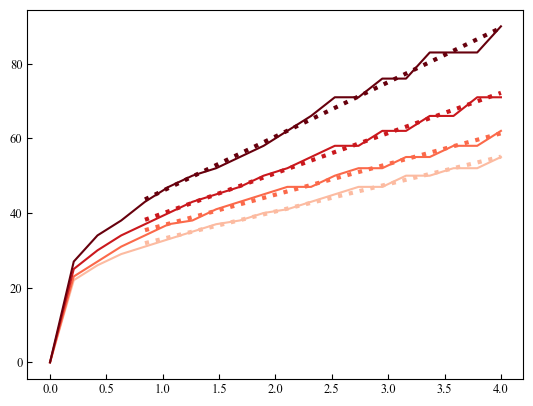

In [17]:
# Plot LIF
handles_dict = {}
labels_dict = {}
slopes_dict = {}

fig, ax = plt.subplots()

for vrest_value in vrest_sorted:
    freqs = freqs_lif[vrest_value]
    mask = I_vals > 0.7
    coef, cov = np.polyfit(I_vals[mask], freqs[mask], 1, cov=True)
    pendiente = coef[0]  # Gain
    slopes_dict[vrest_value] = pendiente
    pendiente_err = np.sqrt(cov[0,0])


    if np.isin(vrest_value, vrest_figures):
        line, = ax.plot(I_vals, freqs, '-', color=color_map[vrest_value])
        ax.plot(I_vals[mask], np.polyval(coef, I_vals[mask]), ':', lw=3, color=color_map[vrest_value])

        handles_dict[vrest_value] = line
        labels_dict[vrest_value] = f"Vr={vrest_value}, {pendiente:.2f}±{pendiente_err:.2f}"

Then QIF is fitted. It is square-root. Slope is only a local linear approximation of the curve $\frac{\sqrt{I}}{\pi}$

In [18]:


# Plot QIF
mask_qif = I_qif > 0.7
coef_qif, cov_qif = np.polyfit(I_qif[mask_qif], freqs_qif[mask_qif], 1, cov=True)
pendiente_qif = coef_qif[0]
slopes_dict['QIF'] = pendiente_qif
pendiente_qif_err = np.sqrt(cov_qif[0,0])

line_qif, = ax.plot(I_qif, freqs_qif, '-', color='steelblue')
ax.plot(I_qif[mask_qif], np.polyval(coef_qif, I_qif[mask_qif]), ':', lw=3, color='steelblue')

handles_dict['QIF'] = line_qif
labels_dict['QIF'] = f"QIF, {pendiente_qif:.2f}±{pendiente_qif_err:.2f}"

# Order handles and labels using vrest_figures (not vrest_sorted)
handles_colors = [handles_dict[vr] for vr in vrest_figures] + [handles_dict['QIF']]
labels_colors = [labels_dict[vr] for vr in vrest_figures] + [labels_dict['QIF']]

# Axis labels
ax.set_xlabel("Current (nA)")
ax.set_ylabel("Firing rate (Hz)")
ax.tick_params(axis='both', direction='in')

# FI and fit legend
line_solid = mlines.Line2D([0],[0], color='gray', lw=3)
line_dotted = mlines.Line2D([0],[0], color='gray', lw=3, linestyle=':')
leg1 = ax.legend(handles=[line_solid, line_dotted], labels=['FI curve', 'Fit'], loc='lower right', bbox_to_anchor=(1,0.37))

# Slopes legend - use vrest_figures instead of vrest_sorted
handles_dotted = [mlines.Line2D([], [], color=color_map[vr], linestyle=':', lw=3) for vr in vrest_figures] + [mlines.Line2D([], [], color='steelblue', linestyle=':', lw=3)]
leg2 = ax.legend(handles=handles_dotted, labels=labels_colors, loc='lower right', bbox_to_anchor=(1,0), title='Gain')

ax.add_artist(leg1)
ax.add_artist(leg2)

fig_path = FIGURES_DIR / "fi_curves_with_slopes.svg"
# plt.savefig(fig_path, dpi=300)
# print(f"Figure saved in '{fig_path}'")
plt.show()